# OCR 

## Import


In [1]:
# import 
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
import struct
from pathlib import Path
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')


/Users/peterschell/Documents/GitHub/AILabs_2025_2026/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## data import


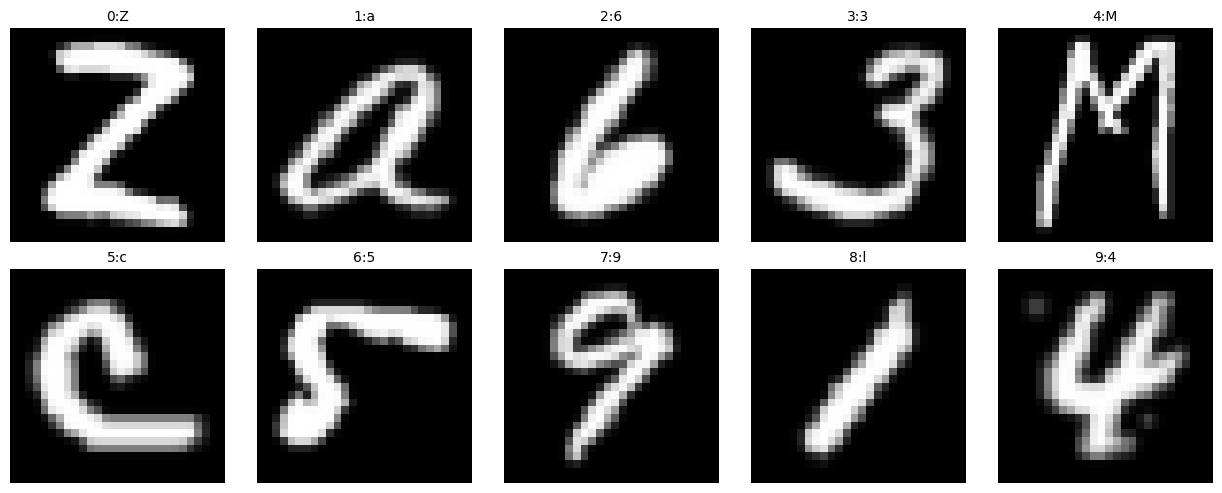

In [4]:
# construction du set d'image 
DATA_DIR = Path("../student_dataset/image_data").resolve()


class MyDataset(Dataset):
    def __init__(self, images_path, labels_path, mapping_path=None):
        images_path = Path(images_path)
        labels_path = Path(labels_path)
        mapping_path = Path(mapping_path) if mapping_path is not None else DATA_DIR / "mapping.txt"

        # Load images
        with open(images_path, "rb") as f:
            magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
            images = np.frombuffer(f.read(), dtype=np.uint8)
            images = images.reshape(num, rows, cols)

        # Load labels
        with open(labels_path, "rb") as f:
            magic, num = struct.unpack(">II", f.read(8))
            labels = np.frombuffer(f.read(), dtype=np.uint8)

        # Load mapping from label index -> ASCII code -> character
        self.mapping = {}
        try:
            with open(mapping_path, "r", encoding="utf-8") as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith("#"):
                        continue
                    idx_str, ascii_str = line.split(" ")
                    idx = int(idx_str)
                    ascii_val = int(ascii_str)
                    self.mapping[idx] = chr(ascii_val)
        except FileNotFoundError:
            raise FileNotFoundError(f"Mapping file not found: {mapping_path}")

        # Fix orientation (rotated)
        images = np.transpose(images, (0, 2, 1)).copy()

        # Convert to PyTorch tensors
        self.images = torch.tensor(images, dtype=torch.float32) / 255.0
        self.labels = torch.tensor(labels, dtype=torch.long)
        # Convert to character labels from mapping
        if not self.mapping:
            raise ValueError("Empty mapping, cannot map label indices to characters")
        self.char_labels = [self.mapping[int(l)] for l in labels]
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx].unsqueeze(0), self.char_labels[idx]

    def show_sample(self, idx=0, count=1):
        if count == 1:
            img, lbl = self[idx]
            img_np = img.squeeze(0).numpy()
            plt.figure(figsize=(4,4))
            plt.imshow(img_np, cmap='gray')
            plt.title(f"Label: {lbl}")
            plt.axis('off')
            plt.show()
            return

        count = min(count, len(self)-idx)
        cols = min(5, count)
        rows = (count + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(cols*2.5, rows*2.5))
        axes = np.array(axes).reshape(-1)

        for i in range(count):
            img, lbl = self[idx + i]
            img_np = img.squeeze(0).numpy()
            ax = axes[i]
            ax.imshow(img_np, cmap='gray')
            ax.set_title(f"{idx+i}:{lbl}", fontsize=10)
            ax.axis('off')

        for i in range(count, len(axes)):
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()


# Paths to your files
images_file = DATA_DIR / "train-images-idx3-ubyte"
labels_file = DATA_DIR / "train-labels-idx1-ubyte"

# Create dataset
dataset = MyDataset(images_file, labels_file)

# Show 10 samples starting at index 0
dataset.show_sample(idx=0, count=10)

## preprocessing des data

Model: "ocr_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,150 (973.24 KB)

 Trainable params: 248,702 (971.49 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 237s 91ms/step - accuracy: 0.6979 - loss: 1.0690 - val_accuracy: 0.8378 - val_loss: 0.4489
Epoch 2/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 211s 86ms/step - accuracy: 0.8282 - loss: 0.4937 - val_accuracy: 0.8441 - val_loss: 0.4164
Epoch 3/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 209s 85ms/step - accuracy: 0.8382 - loss: 0.4578 - val_accuracy: 0.8426 - val_loss: 0.4202
Epoch 4/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 220s 90ms/step - accuracy: 0.8432 - loss: 0.4392 - val_accuracy: 0.8506 - val_loss: 0.3992
Epoch 5/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 211s 86ms/step - accuracy: 0.8471 - loss: 0.4266 - val_accuracy: 0.8525 - val_loss: 0.3893
Epoch 6/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 220s 89ms/step - accuracy: 0.8496 - loss: 0.4157 - val_accuracy: 0.8435 - val_loss: 0.4153
Epoch 7/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 251s 102ms/step - accuracy: 0.8519 - loss: 0.4088 - val_accuracy: 0.8524 - val_loss: 0.3902
Epoch 8/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 247s 101ms/step - accuracy

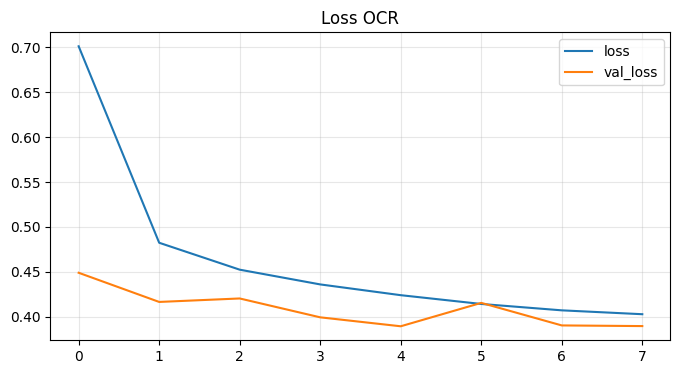

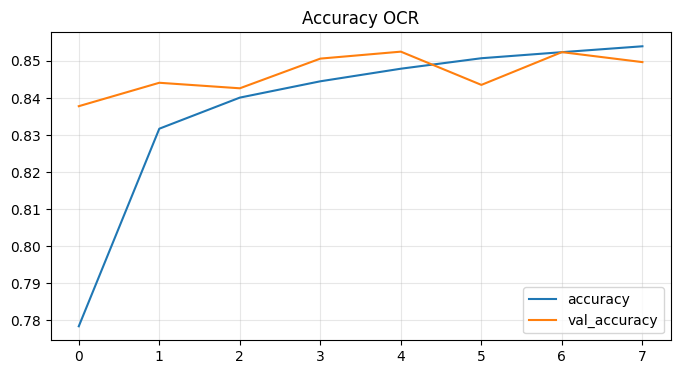

Test loss: 0.3835
Test accuracy: 85.5067%
              precision    recall  f1-score   support

           0       0.62      0.93      0.74      5778
           1       0.62      0.91      0.74      6330
           2       0.95      0.97      0.96      5869
           3       1.00      0.99      0.99      5969
           4       0.98      0.97      0.97      5619
           5       0.92      0.96      0.94      5190
           6       0.97      0.98      0.97      5705
           7       0.99      0.99      0.99      6139
           8       0.98      0.98      0.98      5633
           9       0.92      0.98      0.95      5686
           A       0.95      0.97      0.96      1062
           B       0.92      0.96      0.94       648
           C       0.78      0.93      0.85      1739
           D       0.84      0.93      0.88       779
           E       0.96      0.96      0.96       851
           F       0.75      0.98      0.85      1440
           G       0.91      0.91      

,reel,predit,n
336,O,0,2907
607,l,1,1892
274,I,1,1449
32,1,l,509
625,m,M,459
746,u,U,431
497,c,C,406
530,f,F,376
714,s,S,365
378,S,5,363


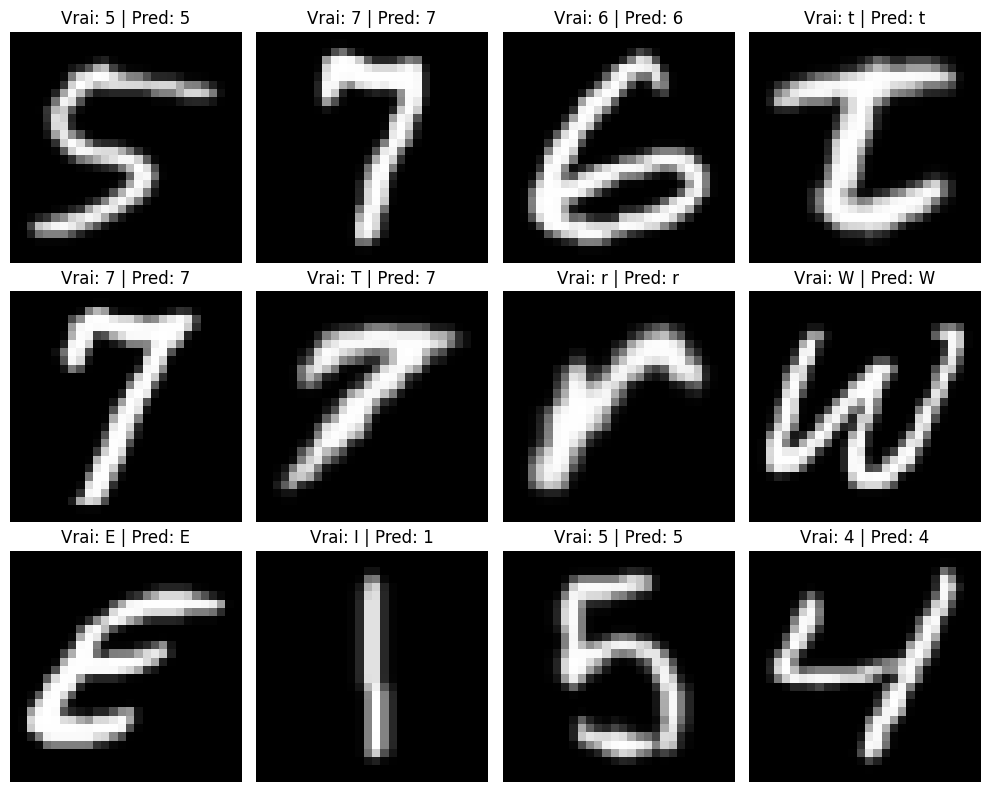

In [5]:


test_images_file = DATA_DIR / "test-images-idx3-ubyte"
test_labels_file = DATA_DIR / "test-labels-idx1-ubyte"

test_dataset = MyDataset(test_images_file, test_labels_file)

class_names = [dataset.mapping[i] for i in sorted(dataset.mapping)]
num_classes = len(class_names)

X_train_full = dataset.images.numpy()[..., np.newaxis]
y_train_full = dataset.labels.numpy().astype("int32")
X_test = test_dataset.images.numpy()[..., np.newaxis]
y_test = test_dataset.labels.numpy().astype("int32")

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.1,
    random_state=0,
    stratify=y_train_full,
)



batch_size = 256
autotune = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(20000, seed=0).batch(batch_size).prefetch(autotune)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(batch_size).prefetch(autotune)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(batch_size).prefetch(autotune)

data_augmentation = keras.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.08, 0.08),
], name="augmentation")

def build_ocr_model(input_shape=(28, 28, 1), num_classes=num_classes):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs=inputs, outputs=outputs, name="ocr_cnn")

model = build_ocr_model()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=[early_stopping],
    verbose=1,
)

history_df = pd.DataFrame(history.history)
history_df[["loss", "val_loss"]].plot(figsize=(8, 4), title="Loss OCR")
plt.grid(alpha=0.3)
plt.show()

history_df[["accuracy", "val_accuracy"]].plot(figsize=(8, 4), title="Accuracy OCR")
plt.grid(alpha=0.3)
plt.show()

test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4%}")

y_proba = model.predict(test_ds, verbose=0)
y_pred = y_proba.argmax(axis=1)

report = classification_report(
    y_test,
    y_pred,
    labels=np.arange(num_classes),
    target_names=class_names,
    zero_division=0,
)
print(report)

cm = confusion_matrix(y_test, y_pred, labels=np.arange(num_classes))
confusions = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confusions.append((class_names[i], class_names[j], int(cm[i, j])))

top_confusions = pd.DataFrame(confusions, columns=["reel", "predit", "n"]).sort_values("n", ascending=False).head(15)
display(top_confusions)

sample_idx = np.random.default_rng(0).choice(len(X_test), size=12, replace=False)
sample_images = X_test[sample_idx]
sample_preds = model.predict(sample_images, verbose=0).argmax(axis=1)

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
for ax, image, true_idx, pred_idx in zip(axes.ravel(), sample_images, y_test[sample_idx], sample_preds):
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Vrai: {class_names[true_idx]} | Pred: {class_names[pred_idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()


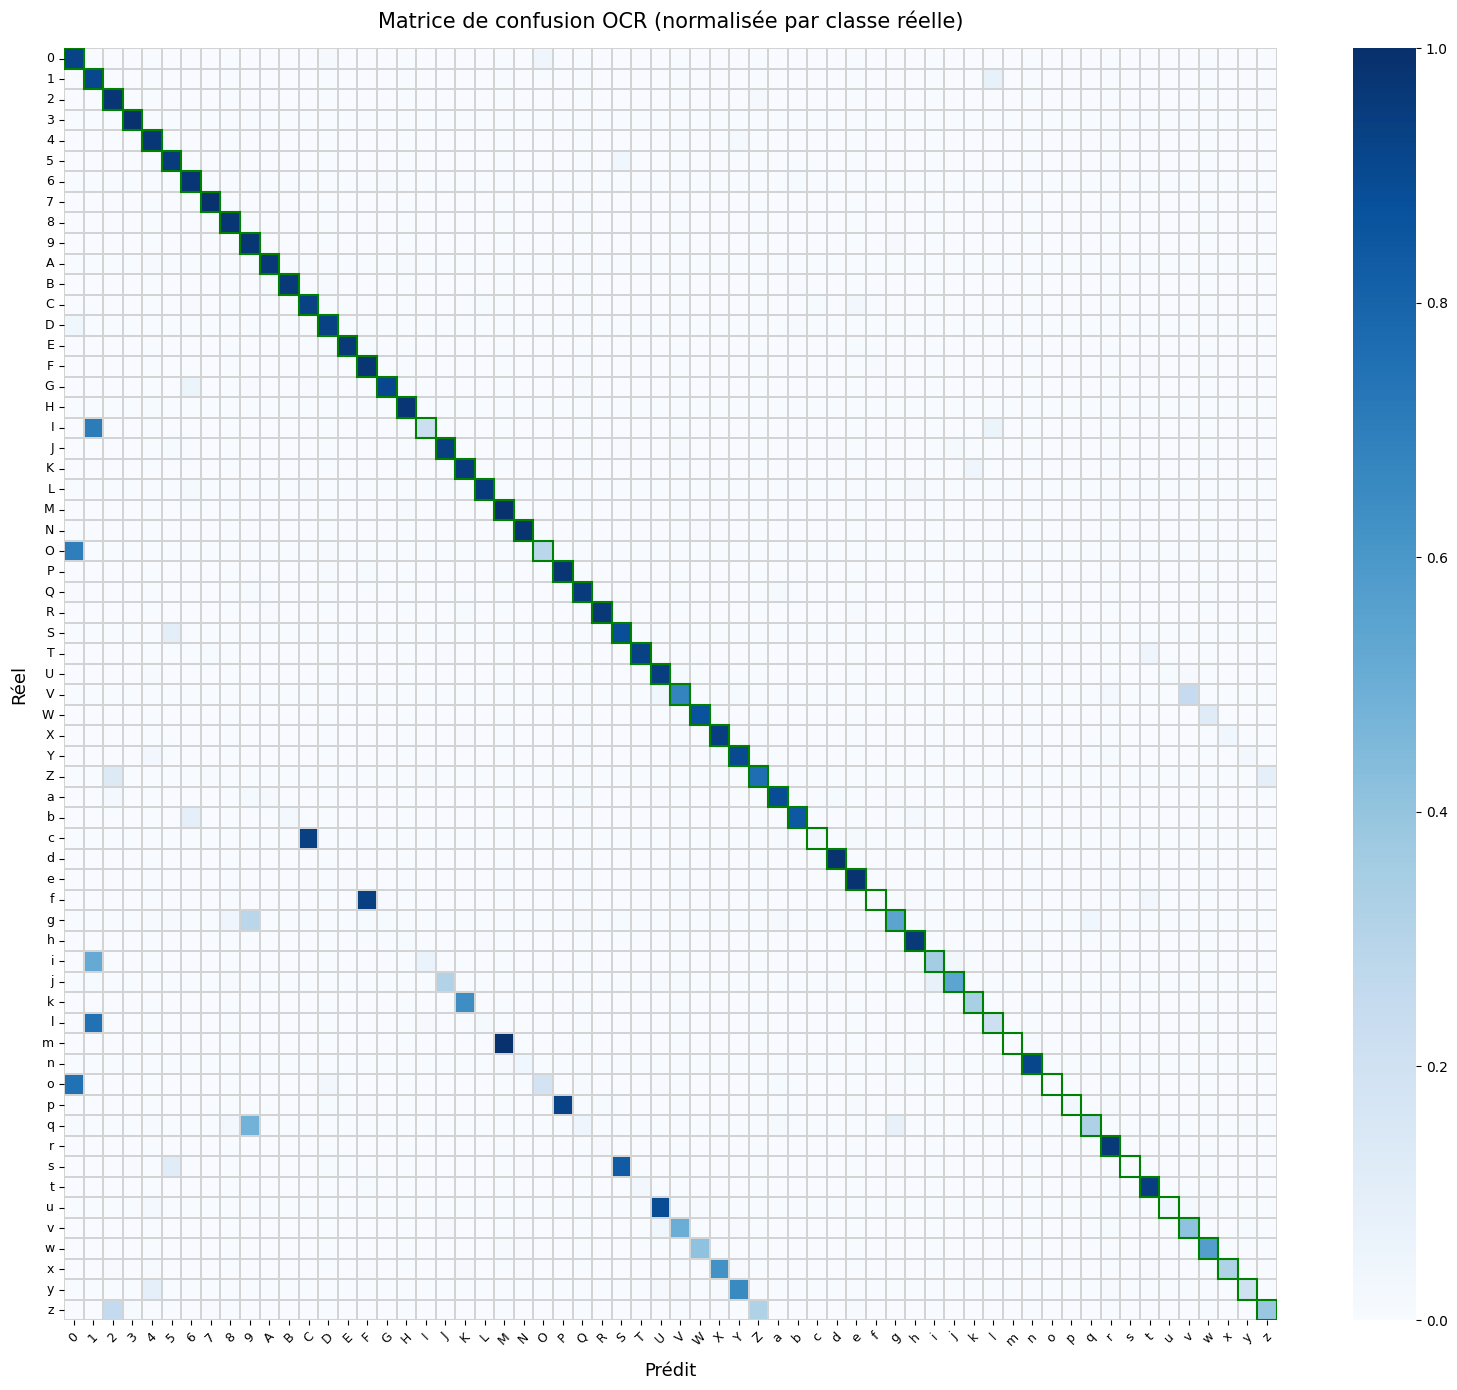

,Réel,Prédit,Nb erreurs,% de la classe réelle
1,O,0,2907,69.9%
2,l,1,1892,74.6%
3,I,1,1449,70.8%
4,1,l,509,8.0%
5,m,M,459,98.9%
6,u,U,431,89.4%
7,c,C,406,94.0%
8,f,F,376,94.0%
9,s,S,365,83.5%
10,S,5,363,10.3%


In [9]:

# matrice de confusion normalisée (couleurs uniquement)
cm = confusion_matrix(y_test, y_pred, labels=np.arange(num_classes))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm_norm,
    annot=False,
    cmap="Blues",
    vmin=0, vmax=1,
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.3,
    linecolor="lightgrey",
    ax=ax,
)
ax.set_xlabel("Prédit", fontsize=13, labelpad=10)
ax.set_ylabel("Réel", fontsize=13, labelpad=10)
ax.set_title("Matrice de confusion OCR (normalisée par classe réelle)", fontsize=15, pad=15)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)

for i in range(len(class_names)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor="green", lw=1.5))

plt.tight_layout()
plt.savefig("../Graph/confusion_matrix_ocr.png", dpi=150)
plt.show()

# Top des plus grosses confusions (erreurs uniquement)
confusions = [
    (class_names[i], class_names[j], int(cm[i, j]), round(cm_norm[i, j] * 100, 1))
    for i in range(num_classes)
    for j in range(num_classes)
    if i != j and cm[i, j] > 0
]
top_confusions = (
    pd.DataFrame(confusions, columns=["Réel", "Prédit", "Nb erreurs", "% de la classe réelle"])
    .sort_values("Nb erreurs", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top_confusions.index += 1
display(top_confusions.style
    .background_gradient(subset=["Nb erreurs"], cmap="Reds")
    .background_gradient(subset=["% de la classe réelle"], cmap="Oranges")
    .format({"% de la classe réelle": "{:.1f}%"})
)
